In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')
sns.set_style('darkgrid')

#ML model imports
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
train = pd.read_csv('C:\misc\housing train.csv')

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train.shape

(1460, 81)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
def drop_nulls(df):
    return df.drop(['Alley', 'PoolQC','Fence','MiscFeature','FireplaceQu'],axis=1)

In [7]:
train = drop_nulls(train)

In [8]:
train.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
654,655,20,RL,91.0,10437,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2008,WD,Normal,350000
411,412,190,RL,100.0,34650,Pave,Reg,Bnk,AllPub,Inside,...,0,0,0,0,0,1,2006,WD,Normal,145000
135,136,20,RL,80.0,10400,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,5,2008,WD,Normal,174000
200,201,20,RM,80.0,8546,Pave,Reg,Lvl,AllPub,Corner,...,0,0,0,0,0,3,2010,WD,Normal,140000
333,334,120,RM,59.0,8198,Pave,Reg,Lvl,AllPub,FR3,...,0,0,0,0,0,7,2008,WD,Normal,207000


In [9]:
def drop_too_many(df):
    cols_to_drop = []
    for column in train.columns:
        #print(column, train[column].nunique())
        if train[column].nunique()>10 and column!='SalePrice':
            cols_to_drop.append(column)
    return df.drop(cols_to_drop,axis=1)

In [10]:
train = drop_too_many(train)

In [11]:
cat_col = train.select_dtypes('object').columns

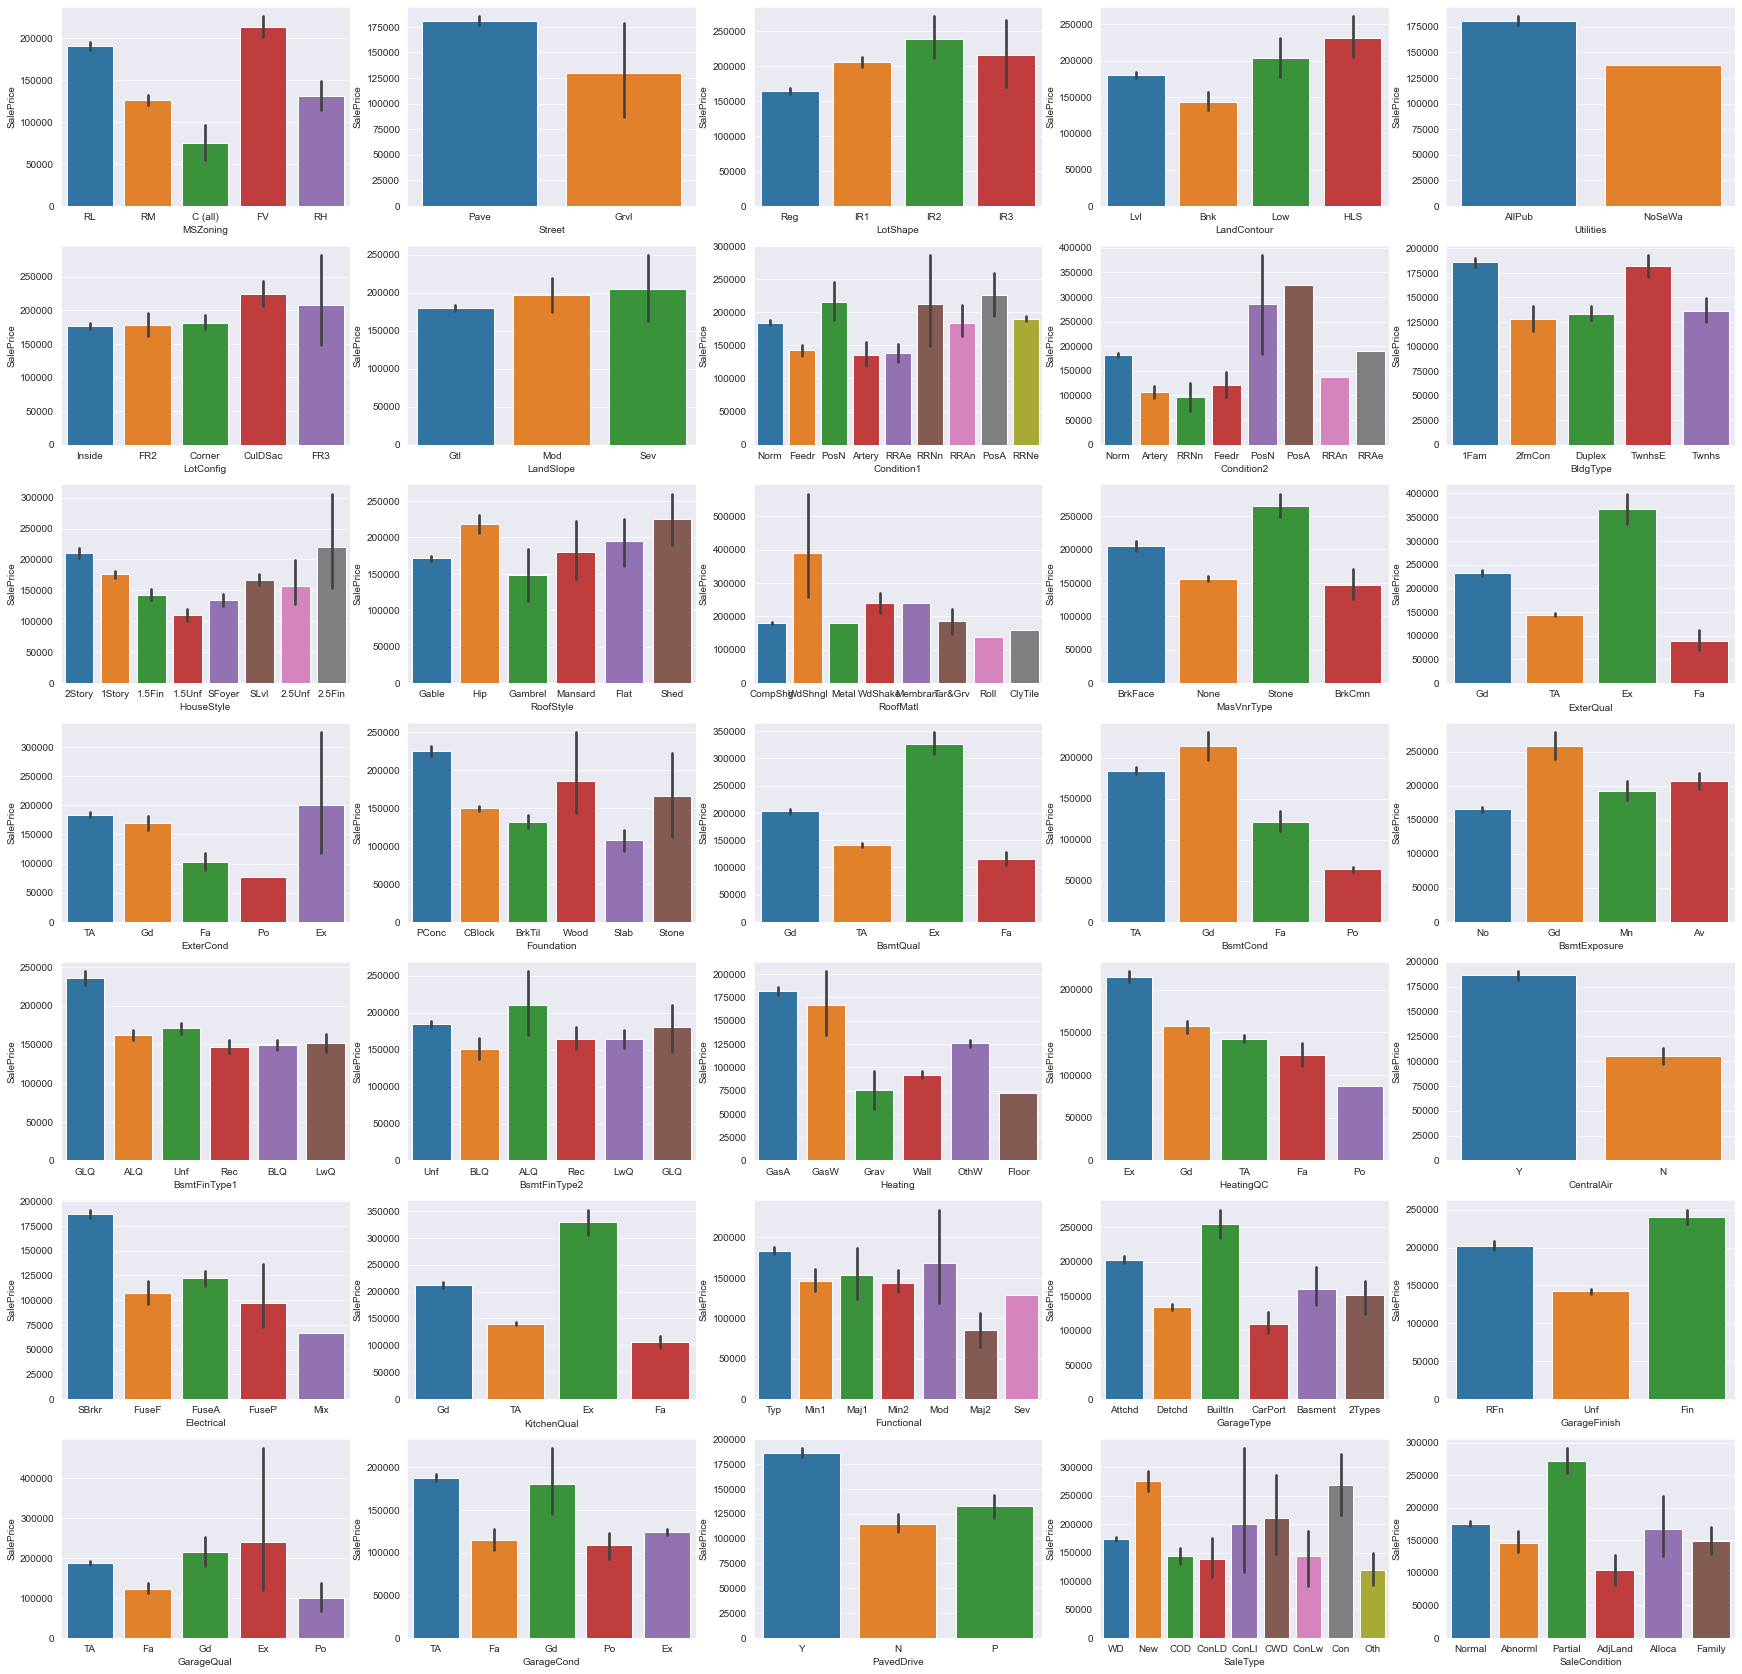

In [12]:
plt.figure(figsize = (30,30))
for i in enumerate(cat_col):
    plt.subplot(7,5,i[0]+1)
    sns.barplot(x=i[1], y='SalePrice',data=train)

In [13]:
train[cat_col] = train[cat_col].fillna('NA')

<AxesSubplot:xlabel='GarageType', ylabel='SalePrice'>

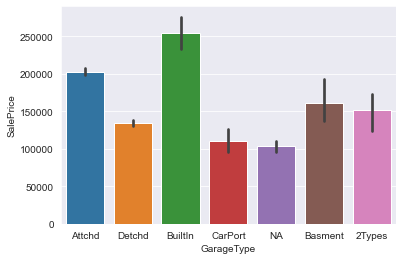

In [14]:
sns.barplot(train['GarageType'],train['SalePrice'])

In [15]:
cols = ['MSZoning', 'LotShape','LandContour','ExterQual','HouseStyle','BsmtQual','HeatingQC','KitchenQual','Street','Utilities','CentralAir','SaleCondition']
def encoding(df, cols):
    df[cols] = df[cols].fillna('NA')
    df['RoofMatl'] = np.where(df['RoofMatl'].str.contains('WdShngl'),1,0)
    df['Electrical'] = np.where(df['Electrical'].str.contains('SBrkr'),1,0)
    label = LabelEncoder()
    for col in cols:
        #print(col)
        loc = df.columns.get_loc(col)
        df.iloc[:,loc] = label.fit_transform(df.iloc[:,loc].values)
    return df

In [16]:
updated = encoding(train,cols)
updated.head()

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Condition1,Condition2,BldgType,...,GarageFinish,GarageCars,GarageQual,GarageCond,PavedDrive,PoolArea,YrSold,SaleType,SaleCondition,SalePrice
0,3,1,3,3,0,Inside,Gtl,Norm,Norm,1Fam,...,RFn,2,TA,TA,Y,0,2008,WD,4,208500
1,3,1,3,3,0,FR2,Gtl,Feedr,Norm,1Fam,...,RFn,2,TA,TA,Y,0,2007,WD,4,181500
2,3,1,0,3,0,Inside,Gtl,Norm,Norm,1Fam,...,RFn,2,TA,TA,Y,0,2008,WD,4,223500
3,3,1,0,3,0,Corner,Gtl,Norm,Norm,1Fam,...,Unf,3,TA,TA,Y,0,2006,WD,0,140000
4,3,1,0,3,0,FR2,Gtl,Norm,Norm,1Fam,...,RFn,3,TA,TA,Y,0,2008,WD,4,250000


In [17]:
train['TotBath'] = train['FullBath'] + train['HalfBath']

In [18]:
num_cols = train.select_dtypes('int64').columns
len(num_cols)

14

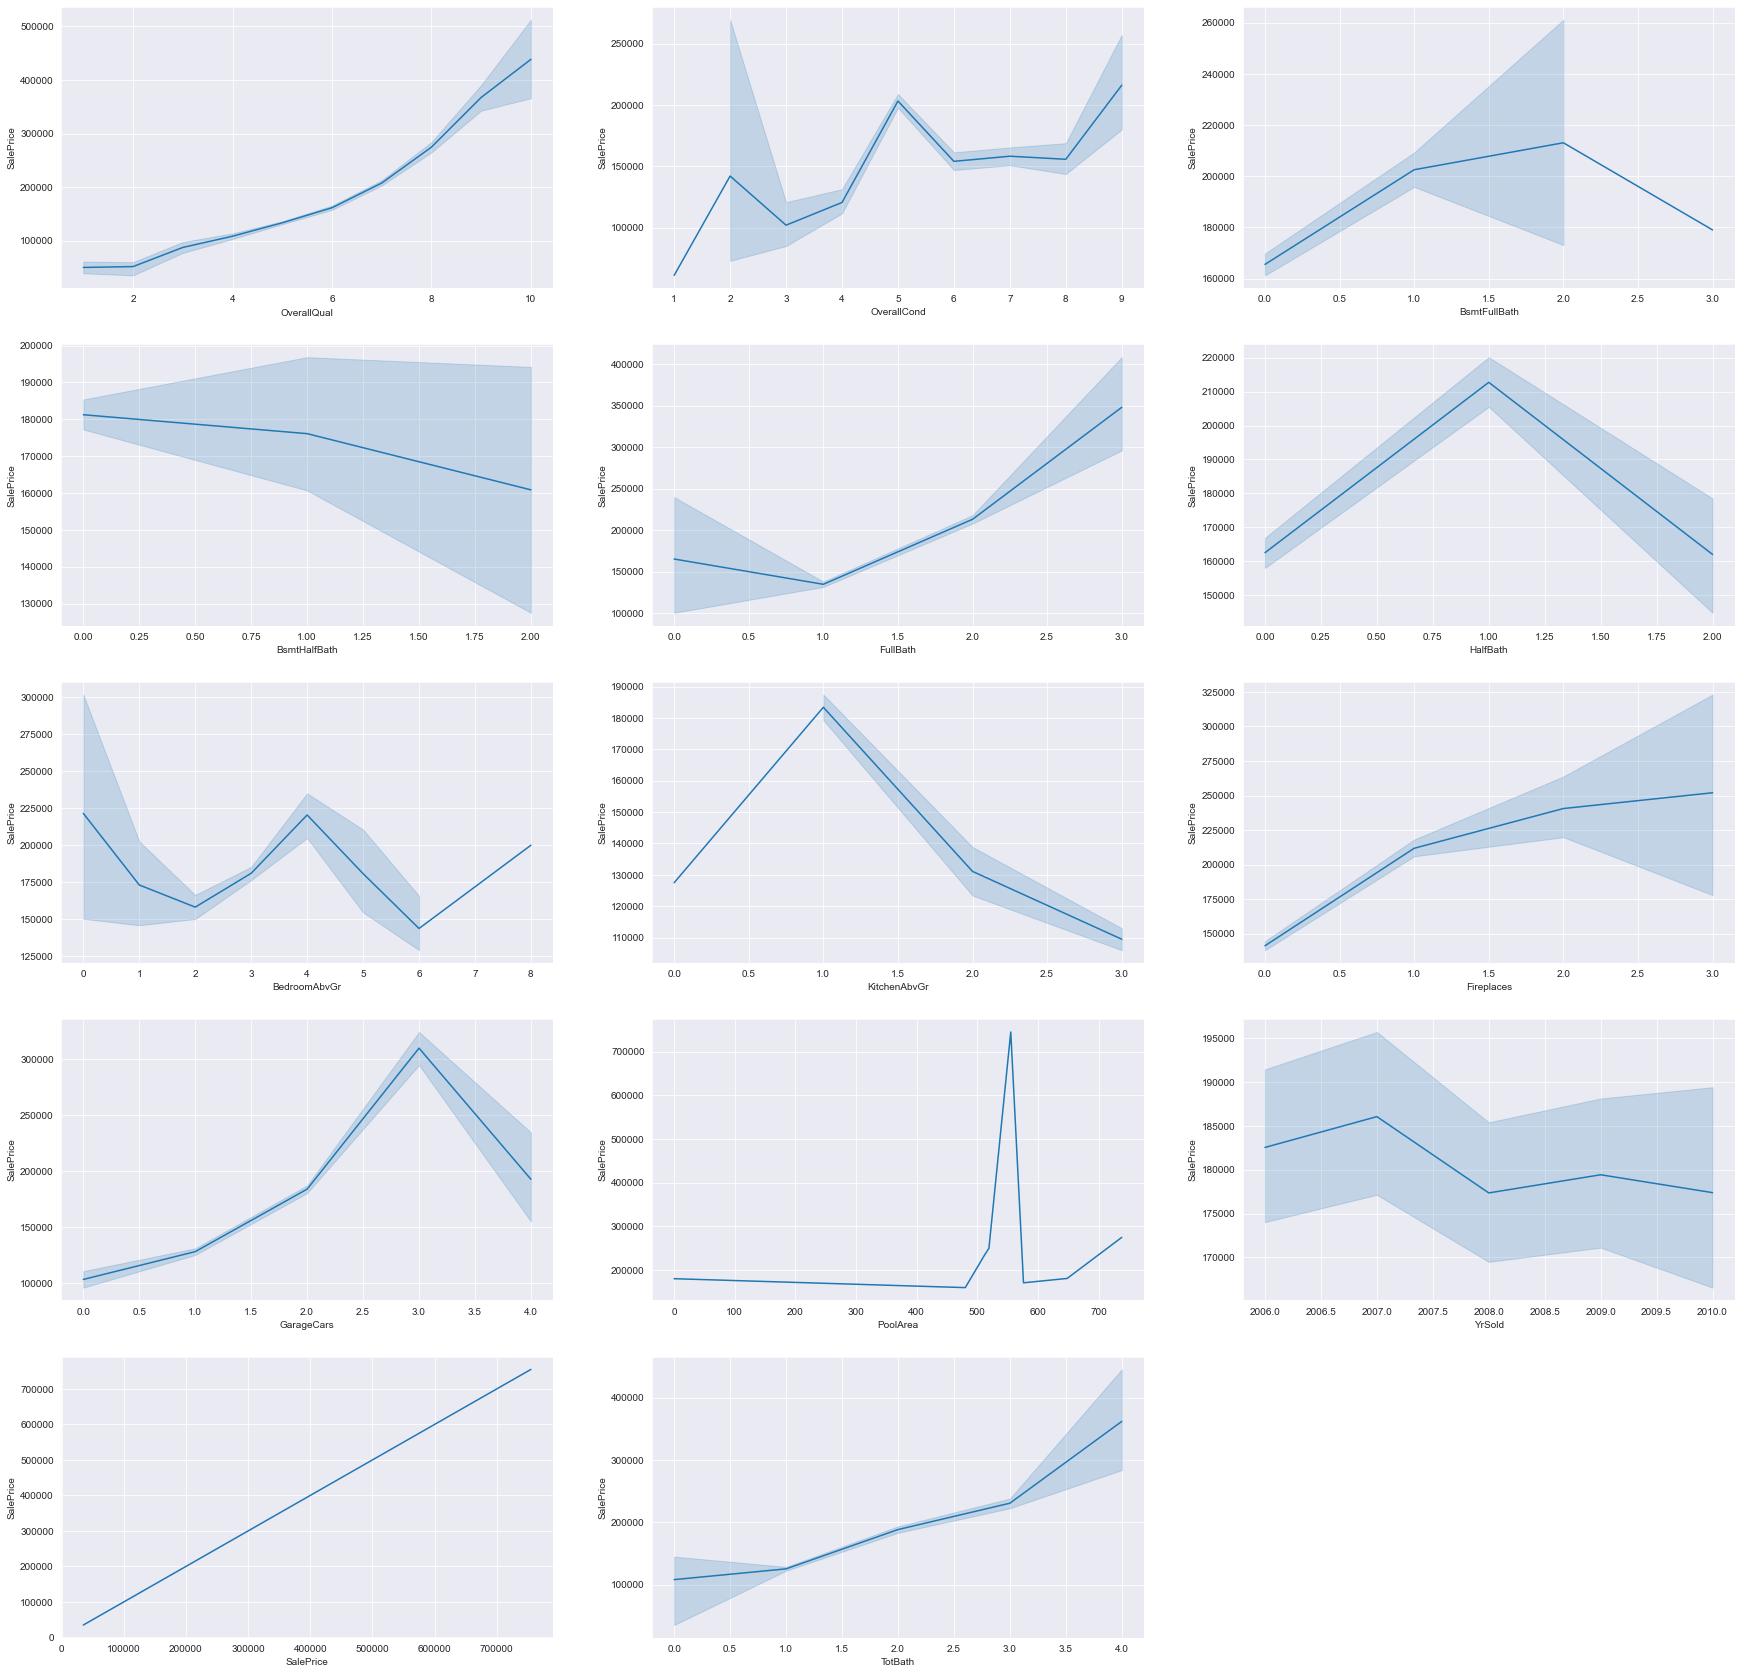

In [19]:
plt.figure(figsize = (30,30))
for i in enumerate(num_cols):
    plt.subplot(5,3,i[0]+1)
    sns.lineplot(x=i[1], y='SalePrice',data=train)

In [20]:
num_cols_keep = ['OverallQual','GarageCars','TotBath','YrSold','Fireplaces','SalePrice']

In [21]:
dataset = pd.concat([train[num_cols_keep],train[train.select_dtypes('int32').columns]],axis=1)

In [22]:
dataset

,OverallQual,GarageCars,TotBath,YrSold,Fireplaces,SalePrice,MSZoning,Street,LotShape,LandContour,Utilities,HouseStyle,RoofMatl,ExterQual,BsmtQual,HeatingQC,CentralAir,Electrical,KitchenQual,SaleCondition
0,7,2,3,2008,0,208500,3,1,3,3,0,5,0,2,2,0,1,1,2,4
1,6,2,2,2007,1,181500,3,1,3,3,0,2,0,3,2,0,1,1,3,4
2,7,2,3,2008,1,223500,3,1,0,3,0,5,0,2,2,0,1,1,2,4
3,7,3,1,2006,1,140000,3,1,0,3,0,5,0,3,4,2,1,1,2,0
4,8,3,3,2008,1,250000,3,1,0,3,0,5,0,2,2,0,1,1,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,2,3,2007,1,175000,3,1,3,3,0,5,0,3,2,0,1,1,3,4
1456,6,2,2,2010,2,210000,3,1,3,3,0,2,0,3,2,4,1,1,3,4
1457,7,1,2,2010,2,266500,3,1,3,3,0,5,0,0,4,0,1,1,2,4
1458,5,1,1,2010,0,142125,3,1,3,3,0,2,0,3,4,2,1,0,2,4


In [23]:
X = dataset.drop('SalePrice',axis=1)
y = dataset['SalePrice']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=420)

In [25]:
def model_select(model,X_train, X_test, y_train, y_test):
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    r2sc = r2_score(y_test,y_pred)
    print(f'Model RMSE Score: {rmse}')
    print(f'Model R2 Score: {r2sc}')
    return [rmse, r2sc]

In [26]:
lr = LinearRegression()
lr_met= model_select(lr,X_train, X_test, y_train, y_test)

Model RMSE Score: 38532.00465300983
Model R2 Score: 0.7477931821296402


In [27]:
rf = RandomForestRegressor()
rf_met = model_select(rf,X_train, X_test, y_train, y_test)

Model RMSE Score: 36228.53679123563
Model R2 Score: 0.77704603385548


In [28]:
knn = KNeighborsRegressor()
knn_met = model_select(knn,X_train, X_test, y_train, y_test)

Model RMSE Score: 42444.89692181034
Model R2 Score: 0.6939695922349407


In [29]:
sgd = SGDRegressor()
sgd_met = model_select(sgd,X_train, X_test, y_train, y_test)

Model RMSE Score: 872354951655266.1
Model R2 Score: -1.2927069258384903e+20


In [30]:
dtree = DecisionTreeRegressor()
dtree_met = model_select(dtree,X_train, X_test, y_train, y_test)

Model RMSE Score: 46404.4867272042
Model R2 Score: 0.6342085405919359


In [80]:
test = pd.read_csv('C:\misc\housing test.csv')

In [81]:
num_cols_keep=['OverallQual', 'GarageCars', 'TotBath', 'YrSold', 'Fireplaces']
test = drop_nulls(test)
test = drop_too_many(test)
test = encoding(test,cols)
test['TotBath'] = test['FullBath'] +test['HalfBath']
to_test = pd.concat([test[num_cols_keep],train[test.select_dtypes('int32').columns]],axis=1)
to_test=to_test.fillna(0)

In [82]:
test_pred = rf.predict(to_test)

In [83]:
test_pred = pd.Series(data=test_pred,name='SalePrice')

In [88]:
return_df = pd.concat([test['Id'],test_preds],axis=1)

In [96]:
return_df.to_csv('C:\misc\submission.csv')

AttributeError: 'DataFrame' object has no attribute 'drop_index'

In [89]:
return_df = return_df.dropna()

In [93]:
return_df['Id'] = return_df['Id'].astype('int32')

In [94]:
return_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1459 entries, 0 to 1458
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         1459 non-null   int32  
 1   SalePrice  1459 non-null   float64
dtypes: float64(1), int32(1)
memory usage: 28.5 KB
